In [9]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from typing import Tuple
from matplotlib.ticker import ScalarFormatter
from copy import deepcopy
import cmath
from types import SimpleNamespace
from scipy.sparse.linalg import eigsh as eigs
import math

def pm_mod(pm, **kwargs):
    pm_lokalne = deepcopy(pm)
    for variable, value in kwargs.items():
        if value is not None:
            setattr(pm_lokalne, variable, value)
    return pm_lokalne

plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10) 

def eV2au(eV: float):
    return 0.03674932587122423*eV

def nm2au(nm: float):
    return 18.89726133921252*nm

def T2au(B: float):
    return 4.254382E-6*B

In [10]:
def onsite_maker(pm: SimpleNamespace):

    def onsite(site):
        (x,y) = site.pos
        return pm.V_np*np.tanh(x/pm.d)
    
    return onsite

def makesystem(pm: SimpleNamespace) -> kwant.system.FiniteSystem | kwant.system.InfiniteSystem:

    '''
    provide system parameters as a dictionary:
    y_min - system's lower boundary in y direction,
    y_max - system's upper boundary in y direction,
    x_min - system's lower boundary in x direction,
    x_max - system's upper boundary in x direction,
    a - lattice constant,
    sf - lattice scaling factor,
    
    t - hopping energy constant,
    V_np - potential amplitude,
    d - potential blur factor,
    B - magnetic field in the z direction

    '''

    t0 = pm.t/pm.sf
    a0 = pm.sf*pm.a

    graphene = kwant.lattice.general ([(0, a0), (np.cos(np.pi/6)*a0, np.sin(np.pi/6)*a0)],
                                    [(0, 0), (a0/np.sqrt(3), 0)],
                                    norbs =1)
    a, b = graphene.sublattices
    
    def shape(pos: tuple) -> bool:
        (x,y) = pos

        return (pm.x_min <= x <= pm.x_max and pm.y_min <= y <= pm.y_max)

    def lead_shape(pos: tuple):
        (x, y) = pos
        return (pm.y_min < y < pm.y_max)
    
    onsite = onsite_maker(pm)
    
    def hopping(site1 , site2):
        
        (x1,y1) = site1.pos
        (x2,y2) = site2.pos

        return -t0*cmath.exp(-0.5j*pm.B*(y2+y1)*(x2-x1))
    
    onsite_llead = pm.V_np*np.tanh(pm.x_min/pm.d)
    onsite_rlead = pm.V_np*np.tanh(pm.x_max/pm.d)

    system = kwant.Builder()
    system[graphene.shape(shape , (0, 0))] = onsite
    system[graphene.neighbors()] = hopping

    llead = kwant.Builder(kwant.TranslationalSymmetry([-np.sqrt(3)*a0, 0]))
    llead[graphene.shape(lead_shape, (pm.x_min, 0))] = onsite_llead
    llead[graphene.neighbors()] = hopping

    rlead = kwant.Builder(kwant.TranslationalSymmetry([np.sqrt(3)*a0, 0]))
    rlead[graphene.shape(lead_shape, (pm.x_max, 0))] = onsite_rlead
    rlead[graphene.neighbors()] = hopping

    system.attach_lead(llead)
    system.attach_lead(rlead)
    system = system.finalized()

    return system

In [11]:
def disperssion(system: kwant.builder.FiniteSystem | kwant.builder.InfiniteSystem,\
                pm: SimpleNamespace, nr_lead: int,\
                k_max: float, n_k_steps: int) -> Tuple[np.ndarray, np.ndarray]:
    
    '''
    Calculate disperssion relation in a lead (nr_lead).
    '''
    dx = np.sqrt(3)*pm.a*pm.sf/2

    bands = kwant.physics.Bands(system.leads[nr_lead])

    ks = np.linspace(-k_max*dx, k_max*dx, n_k_steps)
    Es = [bands(k) for k in ks]

    return (ks/dx, np.asarray(Es))

def plot_disperssion(disperssion: Tuple[np.ndarray, np.ndarray],
                    y_lim: list, name: str = "_") -> None:
    
    ks, energies = disperssion

    if(y_lim[0] == y_lim[1]):
        y_lim[0] = np.min(energies)/eV2au(1.0)
        y_lim[1] = np.max(energies)/eV2au(1.0)
    
    fig, ax = plt.subplots(figsize=(4,4))
    ax.plot(ks*nm2au(1.0), energies/eV2au(1.0), color = 'k')
    ax.set_xlabel(r'$k_x$ (1/nm)')
    ax.set_ylabel(r'$E$ (eV)')
    ax.set_ylim(y_lim[0], y_lim[1])
    ax.grid(True)

    fig.tight_layout()
    plt.savefig(name + ".pdf")
    plt.show()

def conductance(pm: SimpleNamespace,
                bees: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    G = []
    for B in bees:
        S = kwant.smatrix(makesystem(pm_mod(pm, B = B)),
                        energy = 0.0, in_leads = (0,1), out_leads = (0,1))
        G.append(S.transmission(1,0))
    
    return (bees, np.asarray(G))


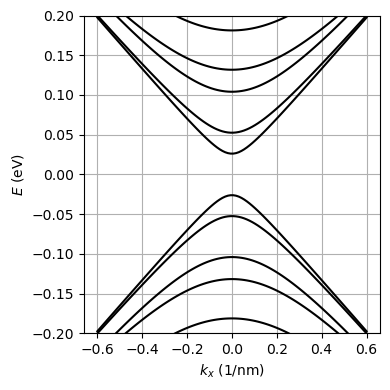

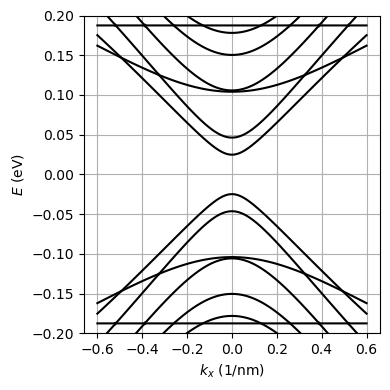

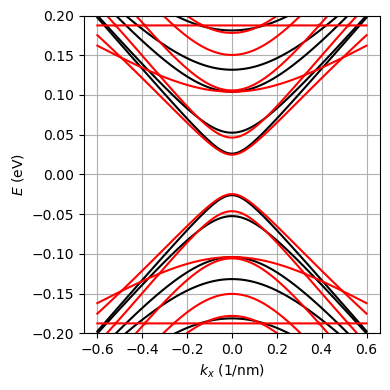

In [12]:
pm = SimpleNamespace(

    y_min = nm2au(-12.9),
    y_max = nm2au(12.9),
    x_min = nm2au(-15.0),
    x_max = nm2au(15.0),
    a = nm2au(0.25),
    sf = 1, # wsp. skalowania sieci
    
    t = eV2au(-3.0),
    V_np = eV2au(0.0), # wysokość potencjału
    d = nm2au(50.0), # wygładzanie potencjału
    B = T2au(0.0)

    )

disps = []
for idx, sf_loc in enumerate([1, 16]):

    pm_loc = pm_mod(pm, sf = sf_loc)
    sys = makesystem(pm_loc)
    disp_result = disperssion(system = sys, pm = pm_loc,
                            nr_lead = 0, k_max = 0.6/nm2au(1.0), n_k_steps= 100)
    plot_disperssion(disp_result, y_lim=[-0.2, 0.2], name = f"zad1_{idx}")
    disps.append(disp_result)

colors = ['k', 'r']
fig, ax = plt.subplots(figsize=(4,4))
for idx, disp_loc in enumerate(disps):
    ks, energies = disp_loc
    ax.plot(ks*nm2au(1.0), energies/eV2au(1.0), color = colors[idx])
ax.set_xlabel(r'$k_x$ (1/nm)')
ax.set_ylabel(r'$E$ (eV)')
ax.set_ylim(-0.2, 0.2)
ax.grid(True)

fig.tight_layout()
plt.savefig("disps.pdf")
plt.show()

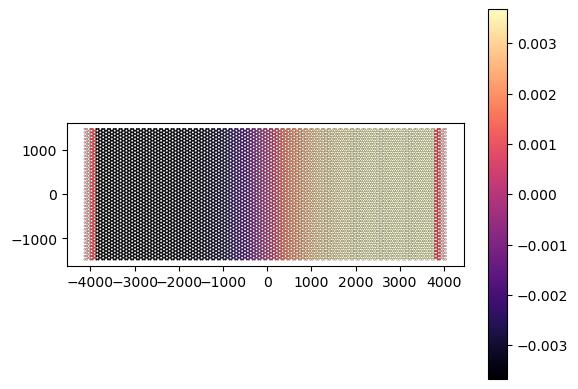

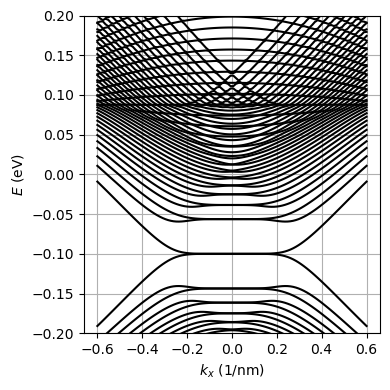

In [13]:
pm2 = SimpleNamespace(

    y_min = nm2au(-79.9),
    y_max = nm2au(79.9),
    x_min = nm2au(-200.0),
    x_max = nm2au(200.0),
    a = nm2au(0.25),
    sf = 16, # wsp. skalowania sieci
    
    t = eV2au(-3.0),
    V_np = eV2au(0.1), # wysokość potencjału
    d = nm2au(50.0), # wygładzanie potencjału
    B = T2au(1.5)

    )

sys = makesystem(pm2)
plot = kwant.plot(sys , site_color = lambda site: sys.hamiltonian(site,site),
        site_lw =0.1, site_size = 0.5, cmap = 'magma', show = False)
plt.savefig("system.pdf")
plt.show()

disp_result = disperssion(system = sys, pm = pm2,
                        nr_lead = 0, k_max = 0.6/nm2au(1.0), n_k_steps= 100)
plot_disperssion(disp_result, y_lim=[-0.2, 0.2], name = f"zad2")

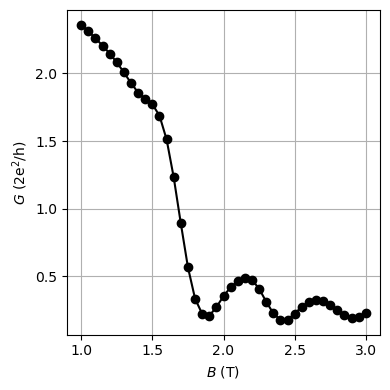

In [14]:
linsp_B = np.arange(T2au(1.0), T2au(3.05), T2au(0.05))
Bs, Gs = conductance(pm = pm2, bees = linsp_B)
fig, ax = plt.subplots(figsize = (4,4))
ax.plot(Bs/T2au(1.0), Gs, color = 'k')
ax.plot(Bs/T2au(1.0), Gs, 'o', color = 'k')
ax.grid(True)
ax.set_xlabel(r'$B$ (T)')
ax.set_ylabel(r'$G$ (2e$^2$/h)')
fig.tight_layout()
plt.savefig("G.pdf")
plt.show()

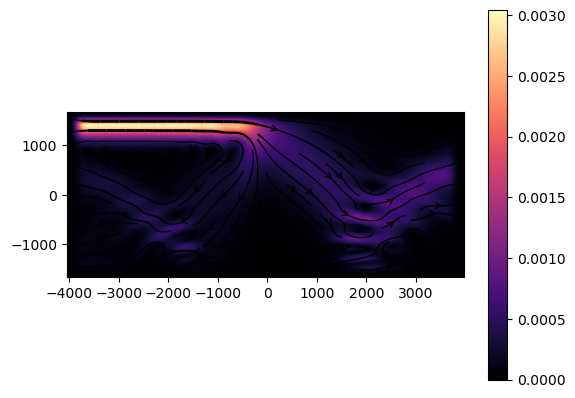

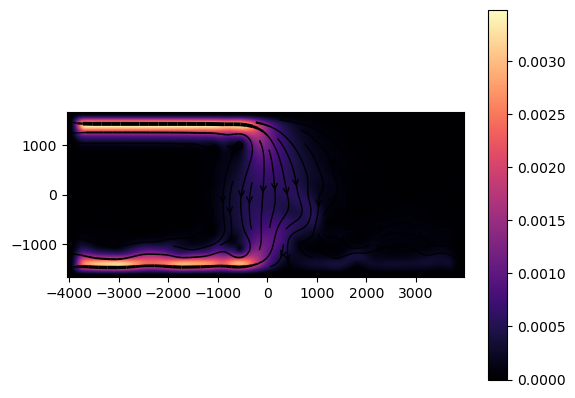

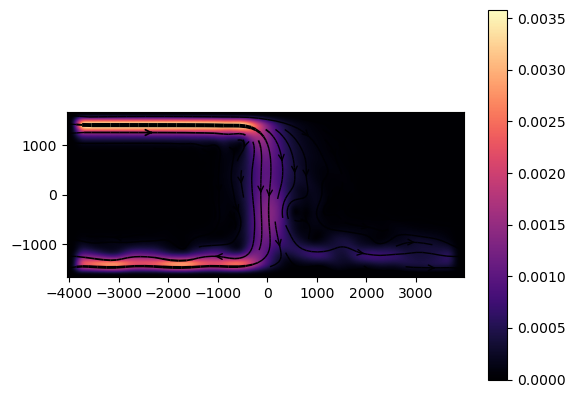

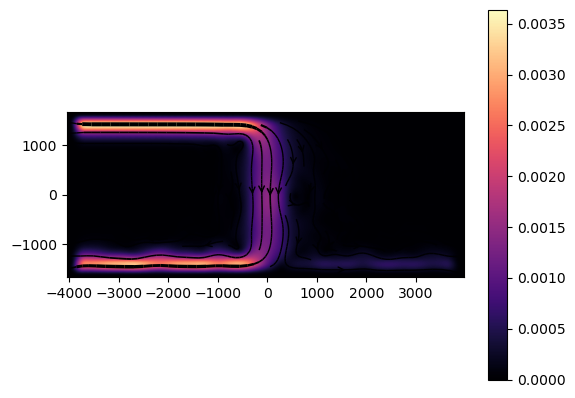

In [15]:
def wave_function(pm: SimpleNamespace, E: float, B: float, nr_lead: int = 0, name: str = "_"):
    
    system = makesystem(pm_mod(pm2, B = B))
    Curr = kwant.operator.Current(system)
    psi = kwant.wave_function(sys = system, energy = E)(nr_lead)

    plot = kwant.plotter.current(system, Curr(psi[0]), cmap = 'magma', show = False)
    plt.savefig(fname = name + ".pdf")
    plt.show()

for enum, b in enumerate([T2au(1.0), T2au(1.9), T2au(2.2), T2au(2.4)]):

    wave_function(pm = pm2, E = eV2au(0.0), B = b, name = f"{enum}")